# Grinding example

This notebook runs the fragmentation population balance model defined in
`grinding.i` and plots the two things a grinding model is expected to show:
the size distribution shifting from the coarse feed toward the fines, and
conservation of total mass. The model, its math, and a walkthrough of the
input file are described on the [](modules-pbm) page.

## Breakage model

This example fixes the two constitutive choices (see [](modules-pbm) for the
population balance equation and the flux operator derivation):

- **Fragmentation rate** -- increasing with size, with a sink at the smallest bin,
  $\gamma_i = 0.05\, i$ (so $\gamma_0 = 0$).
- **Daughter distribution** -- each parent splits its mass equally over all
  smaller bins, $p_{kj} = v_j / (j\, v_k)$ for $k < j$, which conserves mass at
  uniform density.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch

import neml2

torch.set_default_dtype(torch.float64)

Load the input file, fetch the `TransientDriver`, and run the transient. `driver.result()` returns a flat dict of per step buffers keyed `output.<step>.u`.

In [2]:
factory = neml2.load_input("grinding.i")
driver = factory.get_driver("driver")
driver.run()
res = driver.result()

# Bin volumes and time axis match the [Tensors] block in grinding.i.
v = torch.arange(1.0, 21.0)
time = torch.linspace(0.0, 5.0, 25)
steps = sorted(int(k.split(".")[1]) for k in res if k.startswith("output.") and k.endswith(".u"))
u = torch.stack([res[f"output.{s}.u"].detach().reshape(-1) for s in steps])
u.shape

torch.Size([25, 20])

## Size distribution evolution

The coarse Gaussian feed (centered at bin 14) breaks into smaller bins over time; mass accumulates in the low volume sink.

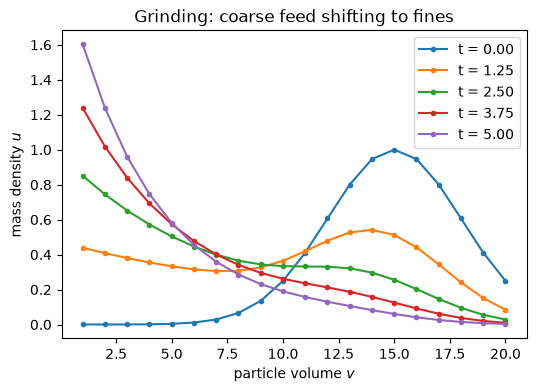

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
for s in [0, 6, 12, 18, 24]:
    ax.plot(v, u[s], marker="o", ms=3, label=f"t = {time[s]:.2f}")
ax.set_xlabel("particle volume $v$")
ax.set_ylabel("mass density $u$")
ax.set_title("Grinding: coarse feed shifting to fines")
ax.legend()
plt.show()

## Mass conservation

The finite-volume flux form with zero-flux boundaries conserves total mass $\sum_i u_i\,\Delta v_i$ (here $\Delta v_i = 1$) to solver tolerance at every step.

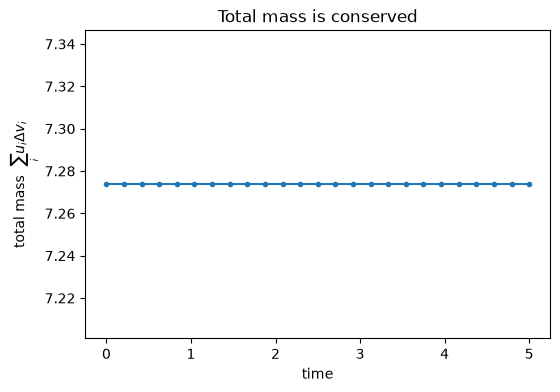

relative mass drift: 2.44e-16


In [4]:
mass = u.sum(dim=1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time, mass, marker="o", ms=3)
ax.set_xlabel("time")
ax.set_ylabel(r"total mass  $\sum_i u_i \Delta v_i$")
ax.set_title("Total mass is conserved")
ax.set_ylim(float(mass.min()) * 0.99, float(mass.max()) * 1.01)
plt.show()
print(f"relative mass drift: {(mass.max() - mass.min()) / mass[0]:.2e}")